# Data-Driven Trading Strategies: Price, Volume, Indicators, and Testing

> **Educational disclaimer:** All strategies, signals, and examples shown in this notebook are for educational and research purposes only. They are not financial advice, investment advice, or recommendations to buy or sell any asset. The examples are simplified and may ignore real-world factors such as transaction costs, slippage, liquidity, taxes, borrowing costs, and market impact.

This notebook introduces the core ideas behind data-driven trading strategies in Python. The goal is not to find a guaranteed profitable system. The goal is to understand the research workflow: define an idea, turn it into rules, test it on data, and interpret the results carefully.

## 1. Introduction: What Is a Data-Driven Trading Strategy?

A **data-driven trading strategy** is a set of trading rules created from observed data. Instead of relying only on opinion, the strategy uses data to decide when to enter, hold, or exit a position.

Trading strategies can broadly be built from two types of data:

### Fundamental data

- interest rates
- GDP growth
- inflation
- unemployment
- company revenues and profits

### Price and volume data

- historical prices
- returns
- trading volume
- volatility

This notebook focuses mainly on **price and volume data**, not fundamental analysis. That is a common starting point for beginner quant workflows because price and volume data is usually cleaner, more structured, and easier to test systematically.

Fundamental data is important, but it is often harder to use because macroeconomic interpretation is complex, company reports require context, and market reactions depend on expectations rather than the event alone.

## 2. Market Inefficiency Concept

The **Efficient Market Hypothesis (EMH)** says, in simple terms, that market prices already reflect available information.

If markets were perfectly efficient, it would be extremely difficult to consistently profit from public information because prices would already adjust instantly and correctly.

In practice, traders still search for small inefficiencies, behavioral patterns, structural effects, or temporary mispricings. Technical indicators and machine learning are often used because they provide systematic ways to search for patterns in price, volume, and volatility.

The hard part is not creating a signal. The hard part is proving that the signal is robust, realistic, and not just overfit noise.

## 3. Types of Technical Indicators

Technical indicators transform price and volume data into signals that may help describe market behavior.

- **Trend indicators** try to identify whether the market is generally moving up, down, or sideways. Moving averages are a classic example.
- **Momentum indicators** measure the speed or strength of price movement. RSI is a common example.
- **Volatility indicators** measure how much prices are moving around. Bollinger Bands are a common example.
- **Volume indicators** use trading volume to study participation or conviction behind price movement.

Indicators are not magic. They are just transformations of market data. Their value depends on how they are tested and used.

## 4. Setup

We use `pandas`, `numpy`, and `matplotlib`. By default, the notebook uses a realistic synthetic OHLCV dataset so it runs quickly and reliably offline.

If you want to try live market data, set `USE_ONLINE_DATA = True` in the code cell below. The notebook will then attempt to download SPY data with `yfinance` and fall back to synthetic data if the download fails.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:,.4f}'.format
plt.style.use('default')

## 5. Load or Create Market Data

For a practical strategy workflow, we need a price series and ideally volume data. The code below returns a DataFrame with `Open`, `High`, `Low`, `Close`, and `Volume` columns.

In [2]:
def create_synthetic_ohlcv(seed=42):
    """Create reproducible synthetic daily OHLCV data as an offline fallback."""
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range(start='2018-01-02', end='2024-12-31')

    daily_returns = rng.normal(loc=0.00035, scale=0.011, size=len(dates))
    close = 250 * np.cumprod(1 + daily_returns)
    open_price = close * (1 + rng.normal(0, 0.0025, len(dates)))
    high = np.maximum(open_price, close) * (1 + rng.uniform(0.001, 0.012, len(dates)))
    low = np.minimum(open_price, close) * (1 - rng.uniform(0.001, 0.012, len(dates)))
    volume = rng.integers(45_000_000, 130_000_000, len(dates))

    data = pd.DataFrame(
        {
            'Open': open_price,
            'High': high,
            'Low': low,
            'Close': close,
            'Volume': volume,
        },
        index=dates,
    )
    data.index.name = 'Date'
    return data


USE_ONLINE_DATA = False


def load_market_data(symbol='SPY', use_online_data=False):
    """Use synthetic data by default; optionally try yfinance first."""
    if not use_online_data:
        return create_synthetic_ohlcv(), 'Synthetic OHLCV data'

    try:
        import yfinance as yf

        downloaded = yf.download(symbol, start='2018-01-01', auto_adjust=False, progress=False, timeout=8)
        if downloaded.empty:
            raise ValueError('yfinance returned an empty dataset.')

        if isinstance(downloaded.columns, pd.MultiIndex):
            downloaded.columns = downloaded.columns.get_level_values(0)

        required_columns = ['Open', 'High', 'Low', 'Close', 'Volume']
        market_data = downloaded[required_columns].dropna().copy()
        market_data.index.name = 'Date'
        return market_data, f'{symbol} data from yfinance'
    except Exception as error:
        print(f'Using synthetic data because yfinance was unavailable or failed: {error}')
        return create_synthetic_ohlcv(), 'Synthetic OHLCV data'


market_data, data_source = load_market_data('SPY', use_online_data=USE_ONLINE_DATA)

print(f'Data source: {data_source}')
print(f'Date range: {market_data.index.min().date()} to {market_data.index.max().date()}')
print(f'Rows: {len(market_data)}')
market_data.head()

Data source: Synthetic OHLCV data
Date range: 2018-01-02 to 2024-12-31
Rows: 1826


,Open,High,Low,Close,Volume
Date,,,,,
2018-01-02,251.4653,252.9372,249.9925,250.9255,62014311
2018-01-03,249.1098,249.9376,246.0869,248.1428,46208107
2018-01-04,249.7298,251.0485,249.0511,250.2780,56328810
2018-01-05,252.8118,255.5912,252.0192,252.9550,63367695
2018-01-08,248.0774,249.7193,244.9724,247.6148,64383629


## 6. Price and Return Basics

Most technical strategies begin with price changes. Here we calculate simple daily returns from closing prices.

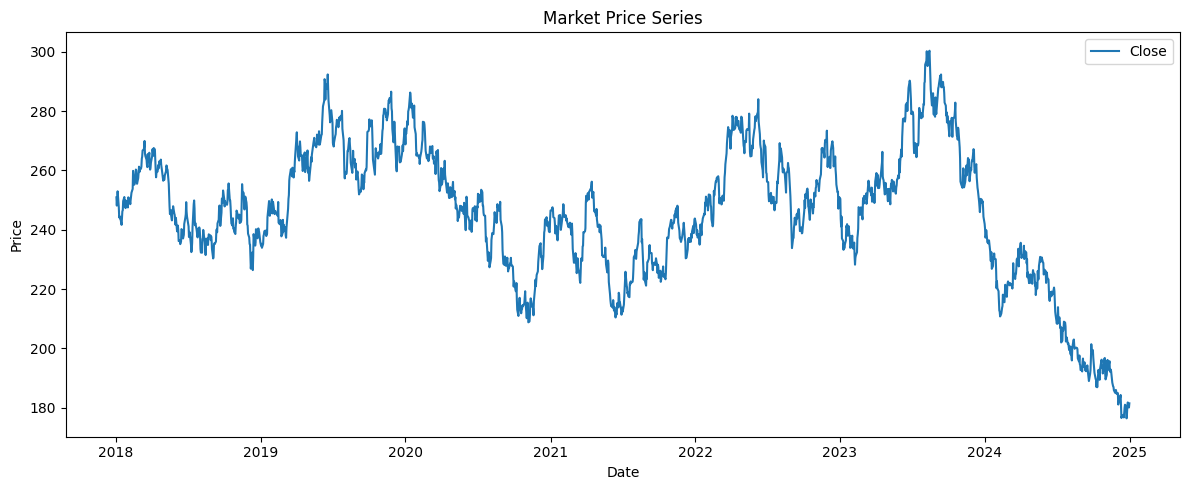

,Close,Return,Volume
Date,,,
2018-01-02,250.9255,NaN,62014311
2018-01-03,248.1428,-0.0111,46208107
2018-01-04,250.2780,0.0086,56328810
2018-01-05,252.9550,0.0107,63367695
2018-01-08,247.6148,-0.0211,64383629


In [3]:
market_data['Return'] = market_data['Close'].pct_change(fill_method=None)

plt.figure(figsize=(12, 5))
plt.plot(market_data.index, market_data['Close'], label='Close')
plt.title('Market Price Series')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

market_data[['Close', 'Return', 'Volume']].head()

## 7. Simple Moving Average (SMA)

A **Simple Moving Average (SMA)** is the average closing price over a fixed window. It smooths price data and helps identify broad trend direction.

Traders might use an SMA to identify whether price is above or below its recent average, or to compare short-term and long-term trend estimates.

In [ ]:
short_sma_window = 20
long_sma_window = 50

market_data['SMA_20'] = market_data['Close'].rolling(short_sma_window).mean()
market_data['SMA_50'] = market_data['Close'].rolling(long_sma_window).mean()

plt.figure(figsize=(12, 5))
plt.plot(market_data.index, market_data['Close'], label='Close', alpha=0.8)
plt.plot(market_data.index, market_data['SMA_20'], label='20-day SMA')
plt.plot(market_data.index, market_data['SMA_50'], label='50-day SMA')
plt.title('Simple Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Exponential Moving Average (EMA)

An **Exponential Moving Average (EMA)** is also a moving average, but it gives more weight to recent prices. This makes it react faster to recent market changes than an SMA.

Traders often use EMAs when they want a trend indicator that responds more quickly.

In [ ]:
market_data['EMA_20'] = market_data['Close'].ewm(span=20, adjust=False).mean()

plt.figure(figsize=(12, 5))
plt.plot(market_data.index, market_data['Close'], label='Close', alpha=0.7)
plt.plot(market_data.index, market_data['SMA_20'], label='20-day SMA')
plt.plot(market_data.index, market_data['EMA_20'], label='20-day EMA')
plt.title('SMA vs EMA')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Bollinger Bands

**Bollinger Bands** combine a moving average with volatility. A common version uses:

- middle band = 20-day SMA
- upper band = SMA + 2 standard deviations
- lower band = SMA - 2 standard deviations

Traders may use Bollinger Bands to study volatility, potential overextension, or mean-reversion ideas.

In [ ]:
bollinger_window = 20
rolling_mean = market_data['Close'].rolling(bollinger_window).mean()
rolling_std = market_data['Close'].rolling(bollinger_window).std()

market_data['BB_Middle'] = rolling_mean
market_data['BB_Upper'] = rolling_mean + 2 * rolling_std
market_data['BB_Lower'] = rolling_mean - 2 * rolling_std

plt.figure(figsize=(12, 5))
plt.plot(market_data.index, market_data['Close'], label='Close')
plt.plot(market_data.index, market_data['BB_Middle'], label='Middle Band')
plt.plot(market_data.index, market_data['BB_Upper'], label='Upper Band')
plt.plot(market_data.index, market_data['BB_Lower'], label='Lower Band')
plt.title('Bollinger Bands')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Relative Strength Index (RSI)

The **Relative Strength Index (RSI)** is a momentum indicator. It compares recent average gains with recent average losses and converts that relationship into a value between `0` and `100`.

A common interpretation is:

- RSI above `70` may indicate overbought conditions
- RSI below `30` may indicate oversold conditions

These thresholds are not universal rules. They are starting points for research.

In [ ]:
def calculate_rsi(close, window=14):
    """Calculate RSI using rolling average gains and losses."""
    price_change = close.diff()
    gains = price_change.clip(lower=0)
    losses = -price_change.clip(upper=0)

    average_gain = gains.rolling(window).mean()
    average_loss = losses.rolling(window).mean()
    relative_strength = average_gain / average_loss

    return 100 - (100 / (1 + relative_strength))


market_data['RSI_14'] = calculate_rsi(market_data['Close'], window=14)

plt.figure(figsize=(12, 4))
plt.plot(market_data.index, market_data['RSI_14'], label='14-day RSI')
plt.axhline(70, linestyle='--', label='Overbought threshold')
plt.axhline(30, linestyle='--', label='Oversold threshold')
plt.title('Relative Strength Index (RSI)')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.legend()
plt.tight_layout()
plt.show()

## 11. MACD

**MACD** stands for Moving Average Convergence Divergence. It compares a faster EMA with a slower EMA.

A common setup is:

- MACD line = 12-day EMA - 26-day EMA
- signal line = 9-day EMA of the MACD line

Traders may look for MACD crossing above or below its signal line as a momentum-style signal.

In [ ]:
ema_12 = market_data['Close'].ewm(span=12, adjust=False).mean()
ema_26 = market_data['Close'].ewm(span=26, adjust=False).mean()

market_data['MACD'] = ema_12 - ema_26
market_data['MACD_Signal'] = market_data['MACD'].ewm(span=9, adjust=False).mean()
market_data['MACD_Histogram'] = market_data['MACD'] - market_data['MACD_Signal']

plt.figure(figsize=(12, 4))
plt.plot(market_data.index, market_data['MACD'], label='MACD')
plt.plot(market_data.index, market_data['MACD_Signal'], label='Signal Line')
plt.axhline(0, linewidth=1)
plt.title('MACD')
plt.xlabel('Date')
plt.ylabel('Indicator Value')
plt.legend()
plt.tight_layout()
plt.show()

# Simple Toy Strategy Examples

The following examples are deliberately simple. They show how indicators can become trading rules, not how to build a production trading system.

For each strategy, we create a signal, shift it by one day to avoid look-ahead bias, calculate simple strategy returns, and compare cumulative performance against buy-and-hold.

In [ ]:
def evaluate_strategy(data, signal_column, strategy_name):
    """Compare a signal-based toy strategy with buy-and-hold."""
    result = data[['Close', 'Return', signal_column]].dropna().copy()

    # Shift the signal so today's position uses yesterday's known signal.
    result['Position'] = result[signal_column].shift(1).fillna(0)
    result['Strategy_Return'] = result['Position'] * result['Return']
    result['Buy_And_Hold'] = (1 + result['Return']).cumprod()
    result['Strategy'] = (1 + result['Strategy_Return']).cumprod()

    plt.figure(figsize=(12, 5))
    plt.plot(result.index, result['Buy_And_Hold'], label='Buy and Hold')
    plt.plot(result.index, result['Strategy'], label=strategy_name)
    plt.title(f'{strategy_name}: Cumulative Returns')
    plt.xlabel('Date')
    plt.ylabel('Growth of $1')
    plt.legend()
    plt.tight_layout()
    plt.show()

    final_buy_hold = result['Buy_And_Hold'].iloc[-1]
    final_strategy = result['Strategy'].iloc[-1]
    print(f'Final buy-and-hold multiple: {final_buy_hold:.3f}x')
    print(f'Final strategy multiple:     {final_strategy:.3f}x')

    return result

## 12. Moving Average Crossover Strategy

A moving average crossover strategy compares a short moving average with a longer moving average.

Toy rule:

- long when `SMA_20 > SMA_50`
- out of the market when `SMA_20 <= SMA_50`

In [ ]:
market_data['MA_Crossover_Signal'] = np.where(market_data['SMA_20'] > market_data['SMA_50'], 1, 0)

plt.figure(figsize=(12, 5))
plt.plot(market_data.index, market_data['Close'], label='Close', alpha=0.7)
plt.plot(market_data.index, market_data['SMA_20'], label='SMA 20')
plt.plot(market_data.index, market_data['SMA_50'], label='SMA 50')
plt.title('Moving Average Crossover Signal')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

ma_strategy_result = evaluate_strategy(market_data, 'MA_Crossover_Signal', 'Moving Average Crossover Strategy')

## 13. RSI Threshold Strategy

An RSI threshold strategy treats very low RSI values as potential oversold conditions.

Toy rule:

- long when `RSI < 30`
- out of the market otherwise

This is a simplified mean-reversion idea.

In [ ]:
market_data['RSI_Signal'] = np.where(market_data['RSI_14'] < 30, 1, 0)

plt.figure(figsize=(12, 4))
plt.plot(market_data.index, market_data['RSI_14'], label='RSI')
plt.axhline(30, linestyle='--', label='Buy threshold')
plt.axhline(70, linestyle='--', label='Upper reference')
plt.title('RSI Threshold Signal')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.legend()
plt.tight_layout()
plt.show()

rsi_strategy_result = evaluate_strategy(market_data, 'RSI_Signal', 'RSI Threshold Strategy')

## 14. Bollinger Band Mean-Reversion Idea

A simple Bollinger Band mean-reversion idea assumes that prices below the lower band may be temporarily stretched.

Toy rule:

- long when price closes below the lower Bollinger Band
- out of the market otherwise

This is not a complete strategy. It is just a clean example of turning an indicator into a signal.

In [ ]:
market_data['Bollinger_Signal'] = np.where(market_data['Close'] < market_data['BB_Lower'], 1, 0)

plt.figure(figsize=(12, 5))
plt.plot(market_data.index, market_data['Close'], label='Close')
plt.plot(market_data.index, market_data['BB_Upper'], label='Upper Band', alpha=0.8)
plt.plot(market_data.index, market_data['BB_Lower'], label='Lower Band', alpha=0.8)
plt.title('Bollinger Band Mean-Reversion Signal')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

bollinger_strategy_result = evaluate_strategy(market_data, 'Bollinger_Signal', 'Bollinger Band Strategy')

## 15. Machine Learning Connection

Machine learning models can use price and volume data in several ways.

They may use raw market features such as:

- recent returns
- volume changes
- volatility estimates

They may also use technical indicators as features:

- SMA distance from price
- RSI
- MACD
- Bollinger Band position

Combining raw data and indicator-based features is common. This notebook does not build a full machine learning trading system, but the feature table below shows what model inputs might look like.

In [ ]:
feature_table = pd.DataFrame(index=market_data.index)

# Lagged returns use only prior information, which is important for realistic modeling.
feature_table['return_lag_1'] = market_data['Return'].shift(1)
feature_table['return_lag_2'] = market_data['Return'].shift(2)
feature_table['return_lag_5'] = market_data['Return'].shift(5)
feature_table['volume_change'] = market_data['Volume'].pct_change(fill_method=None).shift(1)
feature_table['rsi_14'] = market_data['RSI_14'].shift(1)
feature_table['macd'] = market_data['MACD'].shift(1)
feature_table['price_vs_sma_20'] = (market_data['Close'] / market_data['SMA_20'] - 1).shift(1)
feature_table['next_day_return_target'] = market_data['Return'].shift(-1)

feature_table = feature_table.dropna()
feature_table.head()

The feature table above is not a complete ML pipeline. It is just the starting shape: rows are dates, columns are features, and the target is what we might try to predict.

A real ML strategy would need careful train/test splits, walk-forward validation, transaction costs, leakage checks, model diagnostics, and out-of-sample testing.

## Key Takeaways

- Trading strategies can be built from fundamental data or price/volume data.
- This learning path focuses mainly on technical and data-driven strategies using price, returns, volume, and volatility.
- Fundamental analysis is important, but it is outside the main scope here because it often requires deeper economic interpretation and less structured data.
- Technical indicators are structured transformations of price and volume data, not guaranteed trading edges.
- Learning how to create, test, and critique strategies matters more than memorizing every indicator.
- Once you understand the workflow with a few indicators, you can apply the same process to many more ideas.
- Backtesting is only one part of research. Forward testing, realistic costs, and robust validation are essential before taking any strategy seriously.